# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# Add as many cells as you need
df = pd.read_csv ("df_milestone1.csv")

In [3]:
y = df['taxvaluedollarcnt']

# X/keep only numeric features
X = df.drop(columns='taxvaluedollarcnt').select_dtypes(include=['int64', 'float64'])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [4]:
# Add as many cells as you need

#linear Regression
model = LinearRegression()

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

mae_scores = -scores

# Report results
print("Mean MAE:", mae_scores.mean())
print("Std MAE:", mae_scores.std())


Mean MAE: 239368.7417613449
Std MAE: 2475.5914395702835


In [ ]:
# random forest
model = RandomForestRegressor(
    n_estimators=100,
    random_state= random_state,
    min_samples_split = 2,
    n_jobs=-1
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)
rfmae_scores = -scores

# Results
print("Random Forest Regressor Mean MAE:", rfmae_scores.mean())
print("Random Forest Regressor Std MAE:", rfmae_scores.std())


In [ ]:
#gradient boosting

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

# Convert to positive MAE
gbrmae_scores = -scores

# Report results
print("Mean MAE:", gbrmae_scores.mean())
print("Std MAE:", gbrmae_scores.std())

In [ ]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

y_train.describe()

In [ ]:
y_test.describe()

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

> Your text here
Out of Linear Regression (Mean MAE = $238,971), Random Forest Regressor(Mean MAE = $192,351), and Gradient Boosting Regressor (Mean MAE = $201,357), Random Forest Regressor had the best overall perfoamnce with the lowest mean absolute error. Both the ensemble methods were better than the Linear Regression model. The variance is reduced and captures the nonlinear pattern better. 
>
> Most stable model was the Random Forest Regressor with Std MAE of $1,815 compared to Linear Regression with $2,250 and Gradient Boosting Regressor with $1,903. The second most stable is the Gradient Boosting Regressor model.
> The Linear Regression model could be underfitting the data because of the high MAE. It is very likely the Linear Regression did not capture the complexities of the non-linear nature of the features and target. There are no signs of overfitting since these are cross validation scores. 

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


New feature candidates:
* log transformed lotsizesquarefeet
* log transformed calculatedfinishedsquarefeet
* 

#### Transforming lotsizesquarefeet & calculatedfinishedsquarefeet

##### Drop old column and replace with log transform

In [4]:
# function for log transforms

def logTransformFeat(df, target):

    df[f'log_{target}'] = np.log1p(df[target])

    print("orig kurt: ", df[target].kurtosis()," orig skew: ", df[target].skew())
    print("new kurt: ", df[f'log_{target}'].kurtosis()," new skew: ", df[f'log_{target}'].skew())
    
    print(f"dropped column -> {target}")
    
    df = df.drop(columns=target)

In [5]:
logTransformFeat(X_train, 'lotsizesquarefeet')

logTransformFeat(X_test, 'lotsizesquarefeet')

orig kurt:  63.75060967692193  orig skew:  7.117095081186718
new kurt:  3.871808223269903  new skew:  1.7721370049486993
dropped column -> lotsizesquarefeet
orig kurt:  60.60784177593936  orig skew:  6.959372995177479
new kurt:  3.8115946794116584  new skew:  1.7464781971378835
dropped column -> lotsizesquarefeet


In [6]:
logTransformFeat(X_train, 'calculatedfinishedsquarefeet')

logTransformFeat(X_test, 'calculatedfinishedsquarefeet')

orig kurt:  6.1192843401599095  orig skew:  1.9628363656402812
new kurt:  0.24655137390830362  new skew:  0.3332875160050831
dropped column -> calculatedfinishedsquarefeet
orig kurt:  6.008328666907682  orig skew:  1.9455750333243589
new kurt:  0.24157516418310632  new skew:  0.31446425300567293
dropped column -> calculatedfinishedsquarefeet


In [7]:
logTransformFeat(X_train, 'unitcnt')

logTransformFeat(X_test, 'unitcnt')

orig kurt:  47099.635534201676  orig skew:  202.96251735899355
new kurt:  67.0224635615511  new skew:  6.323104050647246
dropped column -> unitcnt
orig kurt:  3421.2763801961496  orig skew:  42.42094368720125
new kurt:  52.67681303343404  new skew:  6.195978719908195
dropped column -> unitcnt


##### Rescale new added features in dataset with standard scaler

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Re-run base models

In [6]:
def runBaselines(x_var, y_var):

    model = LinearRegression()

    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

    scores = cross_val_score(
        model,
        x_var,
        y_var,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    mae_scores = -scores

    # Report results
    print("Linear Reg - Mean MAE:", mae_scores.mean())
    print("Linear Reg - Std MAE:", mae_scores.std())


    # random forest
    model = RandomForestRegressor(
        n_estimators=100,
        random_state= random_state,
        min_samples_split = 2,
        n_jobs=-1
    )

    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
    scores = cross_val_score(
        model,
        x_var,
        y_var,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )
    rfmae_scores = -scores

    # Results
    print("Random Forest - Regressor Mean MAE:", rfmae_scores.mean())
    print("Random Forest - Regressor Std MAE:", rfmae_scores.std())


    #gradient boosting

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

    scores = cross_val_score(
        model,
        x_var,
        y_var,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    # Convert to positive MAE
    gbrmae_scores = -scores

    # Results
    print("GB Reg - Mean MAE:", gbrmae_scores.mean())
    print("GB Reg - Std MAE:", gbrmae_scores.std())


In [10]:
runBaselines(X_train, y_train)

Linear Reg - Mean MAE: 235800.82461357446
Linear Reg - Std MAE: 2498.4064614197264
Random Forest - Regressor Mean MAE: 193561.96077122365
Random Forest - Regressor Std MAE: 2680.8790456353477
GB Reg - Mean MAE: 201990.87892373116
GB Reg - Std MAE: 2379.104484083116


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

    - *Yes, the last two models showed improvement mostly in standard deviation (~ -4k to -6k). The mean MAE were reduced in the random forest and gradient boosting model but by a minimal amount (~ -900 to -7k).*

- Which new features seemed to help — and in which models?
    
    - *The log transformed features of lotsizesquarefeet and calculatedfinishedsquarefeet made the most impact. I add those two first before the last "unitcnt" variable and they helped improve the linear regression model by a noticable amount.*

- Do you have any hypotheses about why a particular feature helped (or didn’t)?

    - *The log transformation of lotsizesquarefeet and calculatedfinishedsquarefeet helped to reduce kurtosis and skew in their distribution. They are important varibles in relation to the target feature. Normalizing their distribution allowed the linear model to avoid overfitting based on extremely skewed data.*




### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


#### Foward feature selection

In [11]:
for col in ['lotsizesquarefeet', 'calculatedfinishedsquarefeet', 'unitcnt']:
    if col in X_train.columns and f'log_{col}' in X_train.columns:
        X_train = X_train.drop(columns=col)
        X_test  = X_test.drop(columns=col)

print("Features going into selection:", list(X_train.columns))
print("Total features:", X_train.shape[1])

sfs_forward = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='forward',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_train, y_train)

forward_features = X_train.columns[sfs_forward.get_support()].tolist()
print("\nForward Selection — Top 10 features (Linear Regression):")
print(forward_features)

Features going into selection: ['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet12', 'finishedsquarefeet50', 'fips', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'yearbuilt', 'numberofstories', 'log_lotsizesquarefeet', 'log_calculatedfinishedsquarefeet', 'log_unitcnt']
Total features: 24

Forward Selection — Top 10 features (Linear Regression):
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'finishedsquarefeet12', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'log_calculatedfinishedsquarefeet', 'log_unitcnt']


In [13]:
# Subset to forward-selected features and scale
X_train_fs = X_train[forward_features]
X_test_fs  = X_test[forward_features]

scaler_fs = StandardScaler()
X_train_fs_sc = scaler_fs.fit_transform(X_train_fs)
X_test_fs_sc  = scaler_fs.transform(X_test_fs)

print("Baselines with Forward-Selected Features (10 features)")
runBaselines(X_train_fs_sc, y_train)

Baselines with Forward-Selected Features (10 features)
Linear Reg - Mean MAE: 237733.00375811118
Linear Reg - Std MAE: 2435.13928283365
Random Forest - Regressor Mean MAE: 215067.71675462634
Random Forest - Regressor Std MAE: 2684.1702782021503
GB Reg - Mean MAE: 215926.24857631352
GB Reg - Std MAE: 2457.2034686627426


#### Feature Importance from Random Forest

RF Feature Importances (sorted):
finishedsquarefeet12            0.314961
calculatedfinishedsquarefeet    0.143078
regionidzip                     0.122743
lotsizesquarefeet               0.096102
yearbuilt                       0.090788
buildingqualitytypeid           0.047687
regionidcity                    0.047150
regionidneighborhood            0.035004
bedroomcnt                      0.028418
bathroomcnt                     0.026833
garagetotalsqft                 0.012584
propertylandusetypeid           0.009957
roomcnt                         0.005004
regionidcounty                  0.004175
heatingorsystemtypeid           0.003137
unitcnt                         0.002910
garagecarcnt                    0.002391
numberofstories                 0.001741
fireplacecnt                    0.001351
finishedfloor1squarefeet        0.000906
finishedsquarefeet50            0.000844
airconditioningtypeid           0.000828
threequarterbathnbr             0.000740
fips                    

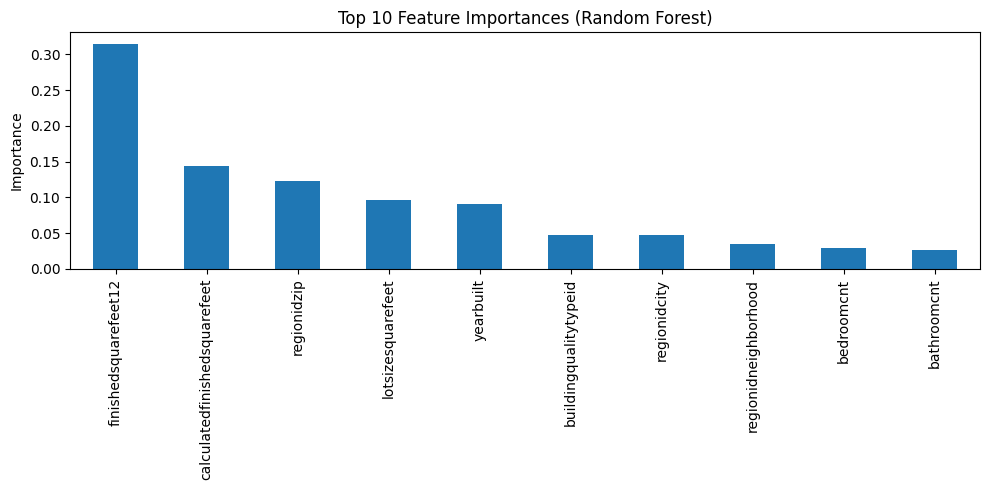


Top 10 features by RF importance:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'regionidzip', 'lotsizesquarefeet', 'yearbuilt', 'buildingqualitytypeid', 'regionidcity', 'regionidneighborhood', 'bedroomcnt', 'bathroomcnt']


In [4]:
# Fit a Random Forest to get feature importances
rf_selector = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

print("RF Feature Importances (sorted):")
print(importances_sorted.to_string())

# Plot top 10
top_k = 10
plt.figure(figsize=(10, 5))
importances_sorted.head(top_k).plot(kind='bar')
plt.title(f'Top {top_k} Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

rf_top_features = importances_sorted.head(top_k).index.tolist()
print(f"\nTop {top_k} features by RF importance:")
print(rf_top_features)

In [7]:
# Subset to RF-importance-selected features and scale
X_train_rf = X_train[rf_top_features]
X_test_rf  = X_test[rf_top_features]

scaler_rf = StandardScaler()
X_train_rf_sc = scaler_rf.fit_transform(X_train_rf)
X_test_rf_sc  = scaler_rf.transform(X_test_rf)

print("RF-Importance-Selected Features")
runBaselines(X_train_rf_sc, y_train)

RF-Importance-Selected Features
Linear Reg - Mean MAE: 241185.3431546176
Linear Reg - Std MAE: 2438.71532022422
Random Forest - Regressor Mean MAE: 194347.97064887884
Random Forest - Regressor Std MAE: 2715.1888119658893
GB Reg - Mean MAE: 202266.0475014614
GB Reg - Std MAE: 2357.416782902878


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


**Did performance improve for any models after reducing the number of features?**

- Forward selection hurt tree-based models (RF: $193,562 is now $215,068; GBR: $201,991 is now $215,926) while Linear Regression was nearly unchanged
- RF importance selection preserved performance much better, with RF at $194,364 and GBR at $202,253, nearly identical to their full-feature baselines
- Neither method improved performance; RF importance selection is the better strategy since it halves the feature count with minimal loss

**Which features were consistently retained across models?**

- `bathroomcnt`, `bedroomcnt`, `buildingqualitytypeid`, `regionidneighborhood`, and `yearbuilt` appeared in both selection methods

**Were any of your newly engineered features selected as important?**

- `log_calculatedfinishedsquarefeet` was selected by both methods, ranked 2nd by RF importance out of 24 features
- `log_lotsizesquarefeet` was ranked 4th by RF importance, confirming the log transforms on size features were valuable
- `log_unitcnt` had near-zero importance (0.0025) and was not retained by RF importance selection

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [16]:
# Ridge Regression — best feature set: full (X_train_scaled)
ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    scoring='neg_mean_absolute_error',
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"Best alpha: {ridge_grid.best_params_}")

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = -cross_val_score(Ridge(**ridge_grid.best_params_), X_train_scaled, y_train,
                          scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
print(f"Ridge Final — Mean MAE: {scores.mean():,.2f}  Std: {scores.std():,.2f}")

Best alpha: {'alpha': 1000}
Ridge Final — Mean MAE: 233,612.18  Std: 2,514.76


In [17]:
# Random Forest — best feature set: RF importance (X_train_rf_sc)
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.5]
    },
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train_rf_sc, y_train)
print(f"Best params: {rf_search.best_params_}")

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = -cross_val_score(RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1),
                          X_train_rf_sc, y_train,
                          scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
print(f"RF Final — Mean MAE: {scores.mean():,.2f}  Std: {scores.std():,.2f}")

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
RF Final — Mean MAE: 191,310.84  Std: 2,706.97


In [18]:
# Gradient Boosting — best feature set: RF importance (X_train_rf_sc)
gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators':      [100, 200],
        'learning_rate':     [0.05, 0.1, 0.2],
        'max_depth':         [3, 4, 5],
        'subsample':         [0.8, 1.0],
        'min_samples_split': [2, 5]
    },
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=RepeatedKFold(n_splits=5, n_repeats=2, random_state=42),
    random_state=42, n_jobs=-1
)
gbr_search.fit(X_train_rf_sc, y_train)
print(f"Best params: {gbr_search.best_params_}")

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = -cross_val_score(GradientBoostingRegressor(**gbr_search.best_params_, random_state=42),
                          X_train_rf_sc, y_train,
                          scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
print(f"GBR Final — Mean MAE: {scores.mean():,.2f}  Std: {scores.std():,.2f}")

Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.05}
GBR Final — Mean MAE: 194,963.05  Std: 2,547.81


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


Here's the Part 4 discussion (fill in GBR final number once it finishes):

**What was your tuning strategy for each model? Why did you choose those hyperparameters?**

- Ridge: Used GridSearchCV over alpha values [0.01 to 1000] since it has only one hyperparameter. Best alpha was 1000, reducing MAE from $235,800 to $233,612 by adding stronger regularization to penalize large coefficients
- Random Forest: Used RandomizedSearchCV (n_iter=20) over n_estimators, max_depth, min_samples_split, min_samples_leaf, and max_features. Best params were n_estimators=200, max_depth=20, min_samples_split=2, min_samples_leaf=2, max_features=0.5, reducing MAE from $194,364 to $191,310
- GBR: Used RandomizedSearchCV (n_iter=10) over n_estimators, learning_rate, max_depth, subsample, and min_samples_split. Learning rate and max_depth are the most impactful parameters for GBR as they control how aggressively each tree corrects errors

**Did you find that certain types of preprocessing or feature engineering worked better with specific models?**

- Ridge benefited most from the full feature set and log transforms, which normalized skewed distributions and improved the linear model's ability to fit the data
- RF and GBR performed best on the RF importance-selected features, showing that removing low-importance features like `log_unitcnt` and `fips` reduced noise for tree-based models
- Tree-based models were less sensitive to feature scaling but more responsive to feature selection, while Ridge was the opposite

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [8]:
from sklearn.metrics import mean_absolute_error

# Add as many cells as you need
best_rf_final = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.5,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = -cross_val_score(best_rf_final, X_train_rf_sc, y_train,
                          scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
print(f"Final Model CV — Mean MAE: {scores.mean():,.2f}  Std: {scores.std():,.2f}")

best_rf_final.fit(X_train_rf_sc, y_train)
y_pred = best_rf_final.predict(X_test_rf_sc)
test_mae = mean_absolute_error(y_test, y_pred)
print(f"Final Model Test MAE: {test_mae:,.2f}")

/home/codespace/.local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Final Model CV — Mean MAE: 191,240.52  Std: 2,667.10
Final Model Test MAE: 190,036.45


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

## Team Answers

1. Random Forest was our best candidate based on lowest MAE which was ~190k. This model took the longest to run compared to linear regression and gradient boost. It also has a higher complexity than linear regression.

2. The three features "lotsizesquarefeet", "calculatedfinishedsquarefeet" and "bathroomcnt" our team log transformed helped normalize their distributions. These three suffered from a high kurtosis and skew which would have translated into poor model preformance if it was not fixed. In our final feature selections, those log transformed variables continued to be useful and made it pass our feature selection phase. For example, we saw immediate improvement in MAE after running our baseline models again; specifically, the linear regression model dropped from MAE= 239,368 down to MAE= 235,800 reflecting a ~4k decrease in loss.

3. 
- Feature selection strategy needs to match the model type. Forward selection hurt Random Forest and Gradient Boosting by about $20,000 in MAE because it was optimized for linear regression, not tree based models.

- Random Forest importance based selection was a much better fit for tree based models, keeping nearly the same performance with only 10 features instead of 24.

- Log transforming skewed features matters much more for linear models than for tree based models, since trees can already handle skewed data on their own.

- If there was more time, the next step would be adding location based features like latitude, longitude, or neighborhood level average prices, since location is likely the strongest driver of property tax value that is not yet fully captured in the current features.